In [ ]:
# Install required packages (run this at the top of your Kaggle notebook)
!pip install git+https://github.com/IDEA-Research/GroundingDINO.git
!pip install git+https://github.com/facebookresearch/segment-anything.git
!pip install opencv-python pycocotools

import torch
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from groundingdino.util.inference import load_model, predict
from segment_anything import sam_model_registry, SamPredictor
import requests
from io import BytesIO
from PIL import Image
import numpy as np
import cv2

# Load chart image from GitHub (ChartQA dataset)
url = "https://raw.githubusercontent.com/vis-nlp/ChartQA/main/ChartQA%20Dataset/test/png/multi_col_1317.png"
response = requests.get(url)
image = Image.open(BytesIO(response.content)).convert("RGB")

# Convert PIL to OpenCV format
image_rgb = np.array(image)  # Already in RGB format for SAM/DINO


# Load Grounding DINO model
CONFIG_PATH = "GroundingDINO/groundingdino/config/GroundingDINO_SwinT_OGC.py"
CKPT_PATH = "/kaggle/input/grounding-dino-weights/groundingdino_swinb_cogcoor.pth"  # upload to kaggle dataset
model = load_model(CONFIG_PATH, CKPT_PATH)


In [12]:
import requests

import torch
from PIL import Image
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

model_id = "IDEA-Research/grounding-dino-tiny"
device = "cuda"

processor = AutoProcessor.from_pretrained(model_id)
model = AutoModelForZeroShotObjectDetection.from_pretrained(model_id).to(device)

image_url = "https://github.com/vis-nlp/ChartQA/raw/main/ChartQA%20Dataset/test/png/multi_col_1317.png"
image = Image.open(requests.get(image_url, stream=True).raw).convert("RGB")


# Check for cats and remote controls
# text_labels = [["a cat", "a remote control"]]

text_labels = [[
    "5k bar", "10k bar", "8k bar"
]]


inputs = processor(images=image, text=text_labels, return_tensors="pt").to(device)
with torch.no_grad():
    outputs = model(**inputs)

results = processor.post_process_grounded_object_detection(
    outputs,
    inputs.input_ids,
    box_threshold=0.4,
    text_threshold=0.3,
    target_sizes=[image.size[::-1]]
)

result = results[0]
for box, score, labels in zip(result["boxes"], result["scores"], result["labels"]):
    box = [round(x, 2) for x in box.tolist()]
    print(f"Detected {labels} with confidence {round(score.item(), 3)} at location {box}")

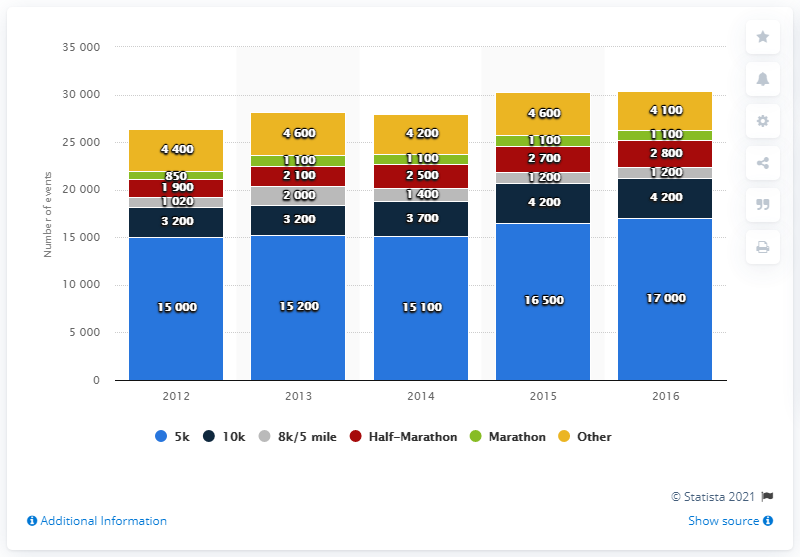

In [13]:
from PIL import Image, ImageDraw, ImageFont
draw = ImageDraw.Draw(image)

# Optional: Load a font
try:
    font = ImageFont.truetype("arial.ttf", 16)
except:
    font = ImageFont.load_default()

for box, score, label in zip(result["boxes"], result["scores"], result["labels"]):
    box = [round(x, 2) for x in box.tolist()]
    label_text = f"{label}: {round(score.item(), 2)}"
    draw.rectangle(box, outline="red", width=2)
    draw.text((box[0], box[1] - 10), label_text, fill="red", font=font)

# Show image with bounding boxes
image

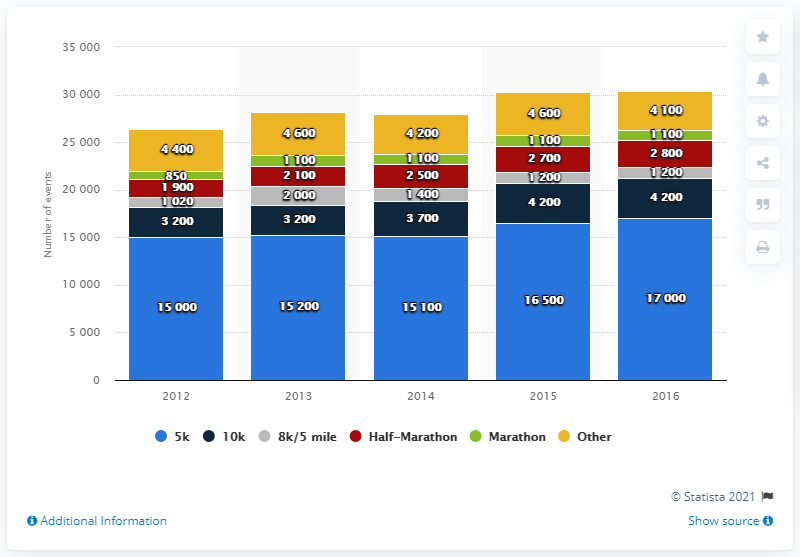

In [11]:

image_url = "https://github.com/vis-nlp/ChartQA/raw/main/ChartQA%20Dataset/test/png/multi_col_1317.png"
image = Image.open(requests.get(image_url, stream=True).raw)
image

segment anything


In [1]:
!pip install git+https://github.com/facebookresearch/segment-anything.git huggingface_hub opencv-python matplotlib requests


  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-tpkmfgsn
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-tpkmfgsn
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done


sam_vit_b_01ec64.pth:   0%|          | 0.00/375M [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/segment_anything/build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f)


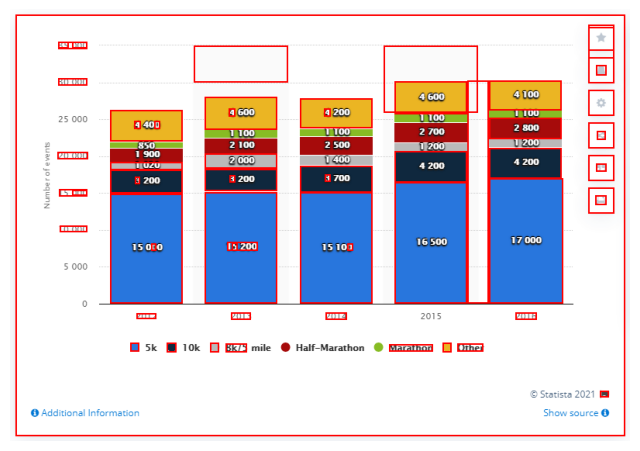

Saved annotated image as chart_with_sam_boxes.png


In [15]:
# 1) Install dependencies (if you haven’t already):
#    pip install git+https://github.com/facebookresearch/segment-anything.git huggingface_hub opencv-python matplotlib requests

import requests
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

from huggingface_hub import hf_hub_download
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

# 2) Download the SAM checkpoint from HF
checkpoint_path = hf_hub_download(
    repo_id="ybelkada/segment-anything",
    filename="checkpoints/sam_vit_b_01ec64.pth"
)

# 3) Build the SAM model
sam = sam_model_registry["vit_b"](checkpoint=checkpoint_path)
mask_generator = SamAutomaticMaskGenerator(sam)

# 4) Load your chart directly from GitHub raw
raw_url = "https://github.com/vis-nlp/ChartQA/raw/main/ChartQA%20Dataset/test/png/multi_col_1317.png"
resp = requests.get(raw_url, stream=True)
img = Image.open(resp.raw).convert("RGB")
img_arr = np.array(img)

# 5) Generate masks for all regions
masks = mask_generator.generate(img_arr)

# 6) Draw bounding-boxes on the image
out = img.copy()
draw = ImageDraw.Draw(out)
for m in masks:
    x, y, w, h = m["bbox"]
    draw.rectangle([x, y, x + w, y + h], outline="red", width=2)

# 7) Display inline with matplotlib
plt.figure(figsize=(8, 6))
plt.axis("off")
plt.imshow(out)
plt.show()

# 8) (Optional) Save to disk
out.save("chart_with_sam_boxes.png")
print("Saved annotated image as chart_with_sam_boxes.png")


2025-04-30 10:08:33.057770: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746007713.500511      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746007713.618858      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


sam_vit_b_01ec64.pth:   0%|          | 0.00/375M [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/segment_anything/build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f)


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

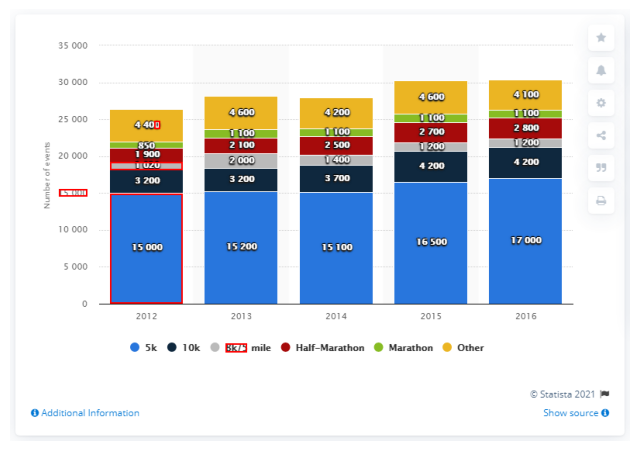

Saved important-region annotated chart as chart_important_regions.png


In [2]:
# 1) Install dependencies (if you haven’t already):
#    pip install git+https://github.com/facebookresearch/segment-anything.git huggingface_hub opencv-python matplotlib requests torch transformers

import requests
import numpy as np
import torch
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

from huggingface_hub import hf_hub_download
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
from transformers import CLIPProcessor, CLIPModel

# ——————————————
# 2) Download & build SAM
checkpoint_path = hf_hub_download(
    repo_id="ybelkada/segment-anything",
    filename="checkpoints/sam_vit_b_01ec64.pth"
)
sam = sam_model_registry["vit_b"](checkpoint=checkpoint_path)
mask_generator = SamAutomaticMaskGenerator(sam)

# ——————————————
# 3) Load CLIP for relevance scoring
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_proc  = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# ——————————————
# 4) Load your chart from GitHub raw
raw_url = "https://github.com/vis-nlp/ChartQA/raw/main/ChartQA%20Dataset/test/png/multi_col_1317.png"
resp = requests.get(raw_url, stream=True)
img  = Image.open(resp.raw).convert("RGB")
img_arr = np.array(img)

# ——————————————
# 5) SAM: propose all masks
masks = mask_generator.generate(img_arr)

# ——————————————
# 6) CLIP: score each mask against the question
question = "How many women ran the 5k race?"
sims = []
for m in masks:
    x,y,w,h = m["bbox"]
    crop = img.crop((x, y, x+w, y+h))
    inputs = clip_proc(text=[question], images=[crop], return_tensors="pt", padding=True)
    with torch.no_grad():
        img_emb = clip_model.get_image_features(pixel_values=inputs.pixel_values)
        txt_emb = clip_model.get_text_features(input_ids=inputs.input_ids, attention_mask=inputs.attention_mask)
    # cosine similarity
    sim = torch.nn.functional.cosine_similarity(img_emb, txt_emb).item()
    sims.append(sim)

# ——————————————
# 7) Select top-K most relevant regions
K = 5
top_idxs = np.argsort(sims)[-K:]
important_masks = [masks[i] for i in top_idxs]

# ——————————————
# 8) Draw only those top-K boxes
out = img.copy()
draw = ImageDraw.Draw(out)
for m in important_masks:
    x,y,w,h = m["bbox"]
    draw.rectangle([x, y, x+w, y+h], outline="red", width=2)

# ——————————————
# 9) Display and save
plt.figure(figsize=(8, 6))
plt.axis("off")
plt.imshow(out)
plt.show()

out.save("chart_important_regions.png")
print("Saved important-region annotated chart as chart_important_regions.png")
